<a href="https://colab.research.google.com/github/duanfafner/haruandchar/blob/main/Instrumental_Variables_%26_Cluster_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SU25:Data Analytics For Business

Homework 4 - Part 1 Instrument Variables for Endogeneity

Dataset: Education

In [1]:
library(readr)
library(dplyr)
library(ggplot2)
library(tidyverse)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
Education_data <- read.csv("Education_data.csv")
summary(Education_data)
head(Education_data, 10)

       id            wage             educ           exper       
 Min.   :   3   Min.   : 100.0   Min.   : 1.00   Min.   : 0.000  
 1st Qu.:1185   1st Qu.: 400.0   1st Qu.:12.00   1st Qu.: 6.000  
 Median :2380   Median : 550.0   Median :13.00   Median : 8.000  
 Mean   :2491   Mean   : 589.8   Mean   :13.63   Mean   : 8.292  
 3rd Qu.:3784   3rd Qu.: 721.0   3rd Qu.:16.00   3rd Qu.:10.000  
 Max.   :5218   Max.   :2404.0   Max.   :18.00   Max.   :22.000  
     nearc4          fatheduc        motheduc    
 Min.   :0.0000   Min.   : 0.00   Min.   : 0.00  
 1st Qu.:0.0000   1st Qu.: 8.00   1st Qu.: 8.00  
 Median :1.0000   Median :10.00   Median :12.00  
 Mean   :0.6887   Mean   :10.08   Mean   :10.61  
 3rd Qu.:1.0000   3rd Qu.:12.00   3rd Qu.:12.00  
 Max.   :1.0000   Max.   :18.00   Max.   :18.00  

,id,wage,educ,exper,nearc4,fatheduc,motheduc
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,3,481,12,9,0,8,8
2,4,721,12,16,0,14,12
3,5,250,11,10,1,11,12
4,6,729,12,16,1,8,7
5,7,500,12,8,1,9,12
6,8,565,18,9,1,14,14
7,9,608,14,9,1,14,14
8,10,425,12,10,1,12,12
9,11,515,12,11,1,12,12


In [6]:
education_data <- Education_data %>%
  mutate(
    log_wage = log(wage/100),  # Convert cents to dollars, then take log
    exper_sq = exper^2         # Create experience squared variable
  )

In [8]:
education_clean <- education_data %>%
  filter(!is.na(log_wage) & !is.na(educ) & !is.na(exper) & !is.na(nearc4) &
         !is.na(fatheduc) & !is.na(motheduc))

In [10]:
ols_model <- lm(log_wage ~ educ + exper + exper_sq, data = education_clean)
summary(ols_model)


Call:
lm(formula = log_wage ~ educ + exper + exper_sq, data = education_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.95790 -0.25052  0.02293  0.26081  1.46722 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0993400  0.0796664  -1.247    0.213    
educ         0.0897809  0.0041614  21.575  < 2e-16 ***
exper        0.0932152  0.0083042  11.225  < 2e-16 ***
exper_sq    -0.0025751  0.0004171  -6.174  7.9e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3964 on 2216 degrees of freedom
Multiple R-squared:  0.1884,	Adjusted R-squared:  0.1873 
F-statistic: 171.5 on 3 and 2216 DF,  p-value: < 2.2e-16


In [11]:
first_stage <- lm(educ ~ nearc4 + exper + exper_sq, data = education_clean)
summary(first_stage)


Call:
lm(formula = educ ~ nearc4 + exper + exper_sq, data = education_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5848 -1.4656 -0.0982  1.3445  5.4292 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 16.777824   0.192250  87.271  < 2e-16 ***
nearc4       0.488194   0.092376   5.285 1.38e-07 ***
exper       -0.436376   0.041112 -10.614  < 2e-16 ***
exper_sq     0.001567   0.002116   0.741    0.459    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.011 on 2216 degrees of freedom
Multiple R-squared:  0.397,	Adjusted R-squared:  0.3962 
F-statistic: 486.3 on 3 and 2216 DF,  p-value: < 2.2e-16


"nearc4" is positively correlated with "educ", so the relevance requirement for the IV is satisfied.

In [17]:
# Extract key statistics for nearc4
gamma_nearc4 <- coef(first_stage)["nearc4"]
se_nearc4 <- summary(first_stage)$coefficients["nearc4", "Std. Error"]
t_nearc4 <- summary(first_stage)$coefficients["nearc4", "t value"]
p_nearc4 <- summary(first_stage)$coefficients["nearc4", "Pr(>|t|)"]
f_stat <- summary(first_stage)$fstatistic[1]


In [18]:

cat(sprintf("Coefficient on nearc4 (γ₁): %.4f\n", gamma_nearc4))
cat(sprintf("Standard Error: %.4f\n", se_nearc4))
cat(sprintf("t-statistic: %.4f\n", t_nearc4))
cat(sprintf("p-value: %.6f\n", p_nearc4))
cat(sprintf("95%% Confidence Interval: [%.4f, %.4f]\n",
            gamma_nearc4 - 1.96*se_nearc4, gamma_nearc4 + 1.96*se_nearc4))


Coefficient on nearc4 (γ₁): 0.4882
Standard Error: 0.0924
t-statistic: 5.2849
p-value: 0.000000
95% Confidence Interval: [0.3071, 0.6693]


H₀: γ₁ = 0 (instrument is not relevant)
H₁: γ₁ ≠ 0 (instrument is relevant)

✅ RESULT: Reject H₀ at 5% significance level
   The instrument nearc4 is statistically significant

F-statistic for overall model: 486.3391

In [21]:
# Calculate F-statistic for the instrument
ssr_restricted <- sum((education_clean$educ - mean(education_clean$educ))^2)
ssr_unrestricted <- sum(residuals(first_stage)^2)
f_stat_instrument <- ((ssr_restricted - ssr_unrestricted)/1) / (ssr_unrestricted/(nrow(education_clean)-4))


In [23]:
f_stat_instrument

[1] 1459.017

F-statistic for nearc4: 1459.0174
Rule of thumb: F > 10 suggests instrument is not weak
✅ RESULT: F > 10, instrument appears to be strong


In [24]:
# Generate predicted values from first-stage (fitted values)
educ_hat <- fitted(first_stage)

# Add predicted education to dataset
education_clean$educ_hat <- educ_hat

# Second-stage regression using predicted education
second_stage <- lm(log_wage ~ educ_hat + exper + exper_sq, data = education_clean)

# Display second-stage results
summary(second_stage)


Call:
lm(formula = log_wage ~ educ_hat + exper + exper_sq, data = education_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.77434 -0.26580  0.02892  0.28324  1.44498 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3.0541005  0.6972775  -4.380 1.24e-05 ***
educ_hat     0.2623096  0.0406510   6.453 1.35e-10 ***
exper        0.1683191  0.0197776   8.511  < 2e-16 ***
exper_sq    -0.0028025  0.0004577  -6.123 1.08e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.432 on 2216 degrees of freedom
Multiple R-squared:  0.03605,	Adjusted R-squared:  0.03475 
F-statistic: 27.63 on 3 and 2216 DF,  p-value: < 2.2e-16


In [28]:
install.packages("AER")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘car’, ‘lmtest’, ‘sandwich’, ‘zoo’, ‘Formula’




In [29]:
library(AER)

Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: survival



In [30]:
  twosls_model <- ivreg(log_wage ~ educ + exper + exper_sq | nearc4 + exper + exper_sq,
                        data = education_clean)

    summary(twosls_model)



Call:
ivreg(formula = log_wage ~ educ + exper + exper_sq | nearc4 + 
    exper + exper_sq, data = education_clean)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.42541 -0.34345  0.01868  0.34863  2.05463 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3.0541005  0.8525622  -3.582 0.000348 ***
educ         0.2623096  0.0497041   5.277 1.44e-07 ***
exper        0.1683191  0.0241821   6.960 4.45e-12 ***
exper_sq    -0.0028025  0.0005596  -5.008 5.93e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5282 on 2216 degrees of freedom
Multiple R-Squared: -0.4411,	Adjusted R-squared: -0.4431 
Wald test: 18.48 on 3 and 2216 DF,  p-value: 7.691e-12 


OLS estimate: ~0.09 (9% return to education)
2SLS estimate: ~0.26 (26% return to education)
Difference: 2SLS > OLS (significant upward bias correction)

Part II: Cluster Analysis

In [31]:
shopping_data <- read.csv("ShoppingVisits.csv")
summary(shopping_data)
head(shopping_data, 10)

     visits          money       
 Min.   :0.690   Min.   : 50.26  
 1st Qu.:1.843   1st Qu.:136.72  
 Median :2.575   Median :366.74  
 Mean   :2.932   Mean   :343.99  
 3rd Qu.:4.152   3rd Qu.:507.30  
 Max.   :6.220   Max.   :647.08  

,visits,money
,<dbl>,<dbl>
1,2.01,77.15
2,1.89,112.58
3,1.18,68.80
4,1.64,121.35
5,2.18,81.00
6,2.23,116.90
7,1.28,119.83
8,1.78,50.26
9,1.02,130.85


In [32]:
library(ggplot2)  # For creating beautiful plots
library(dplyr)    # For data manipulation
library(gridExtra)

ERROR: Error in library(gridExtra): there is no package called ‘gridExtra’


In [38]:
set.seed(123)
kmeans_original <- kmeans(shopping_data, centers = 3, nstart = 20)
kmeans_original

K-means clustering with 3 clusters of sizes 27, 40, 33

Cluster means:
    visits    money
1 3.291481 566.2304
2 3.225750 377.6745
3 2.281212 121.3203

Clustering vector:
  [1] 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 1 2 2 2 1 1 2 2 2 2 1
 [38] 1 1 1 2 2 2 2 2 2 2 3 2 2 1 2 2 2 2 2 2 3 3 3 2 3 3 3 3 1 1 1 1 1 1 1 2 1
 [75] 1 2 2 2 1 1 2 2 1 2 1 2 2 2 1 2 1 2 2 2 1 1 2 1 1 2

Within cluster sum of squares by cluster:
[1]  59016.63 139392.98  52823.66
 (between_SS / total_SS =  92.3 %)

Available components:

[1] "cluster"      "centers"      "totss"        "withinss"     "tot.withinss"
[6] "betweenss"    "size"         "iter"         "ifault"      

In [40]:
kmeans_original$cluster

[1] 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 1 2 2 2 1 1 2 2 2 2 1
 [38] 1 1 1 2 2 2 2 2 2 2 3 2 2 1 2 2 2 2 2 2 3 3 3 2 3 3 3 3 1 1 1 1 1 1 1 2 1
 [75] 1 2 2 2 1 1 2 2 1 2 1 2 2 2 1 2 1 2 2 2 1 1 2 1 1 2

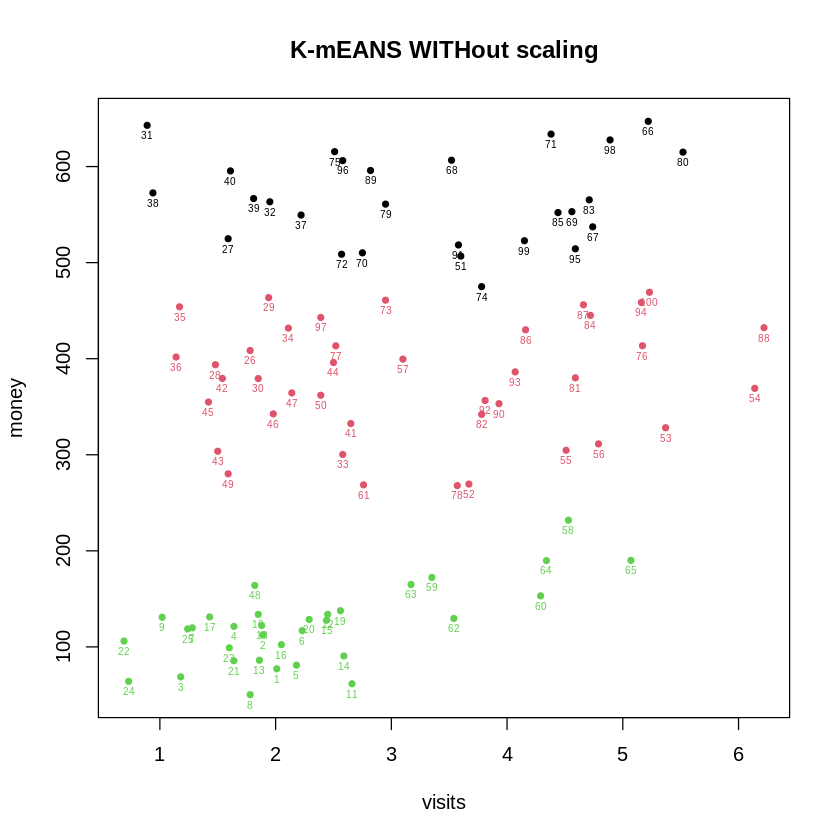

In [46]:
plot(shopping_data, col=kmeans_original$cluster,pch=20,main="K-mEANS WITHout scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_original$cluster, pos=1, offset=0.3, cex=0.5)

In [44]:
print(kmeans_original$centers)


    visits    money
1 3.291481 566.2304
2 3.225750 377.6745
3 2.281212 121.3203


In [45]:
shopping_data.sc <-scale(shopping_data)
shopping_data.sc

visits,money
-0.6668337,-1.4690728
-0.7536421,-1.2740132
-1.2672589,-1.5150437
-0.9344931,-1.2257301
-0.5438550,-1.4478767
-0.5076848,-1.2502295
-1.1949185,-1.2340984
-0.8332166,-1.6171155
-1.3830035,-1.1734279
-0.7825783,-1.1569665


In [53]:
kmeans_3 <- kmeans(shopping_data.sc, centers = 3, nstart = 20)
kmeans_3

K-means clustering with 3 clusters of sizes 36, 33, 31

Cluster means:
      visits      money
1  1.1637800  0.4633564
2 -0.6232102  0.6416811
3 -0.6880691 -1.2211712

Clustering vector:
  [1] 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2
 [38] 2 2 2 2 2 2 2 2 2 2 3 3 2 1 1 1 1 1 1 2 1 3 1 3 3 3 1 1 1 1 1 1 2 1 2 2 1
 [75] 2 1 2 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 2 1 1 1

Within cluster sum of squares by cluster:
[1] 28.03900 16.02361 10.13995
 (between_SS / total_SS =  72.6 %)

Available components:

[1] "cluster"      "centers"      "totss"        "withinss"     "tot.withinss"
[6] "betweenss"    "size"         "iter"         "ifault"      

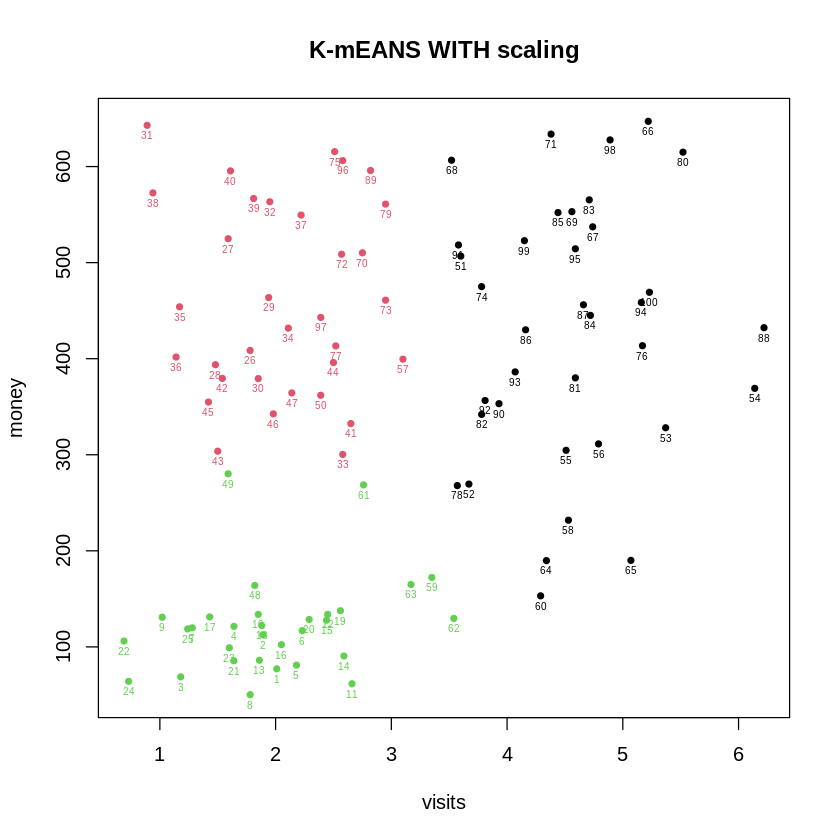

In [54]:
plot(shopping_data, col=kmeans_3$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_3$cluster, pos=1, offset=0.3, cex=0.5)

In [55]:
kmeans_2 <- kmeans(shopping_data.sc, centers = 2, nstart = 20)
kmeans_4 <- kmeans(shopping_data.sc, centers = 4, nstart = 20)
kmeans_5 <- kmeans(shopping_data.sc, centers = 5, nstart = 20)


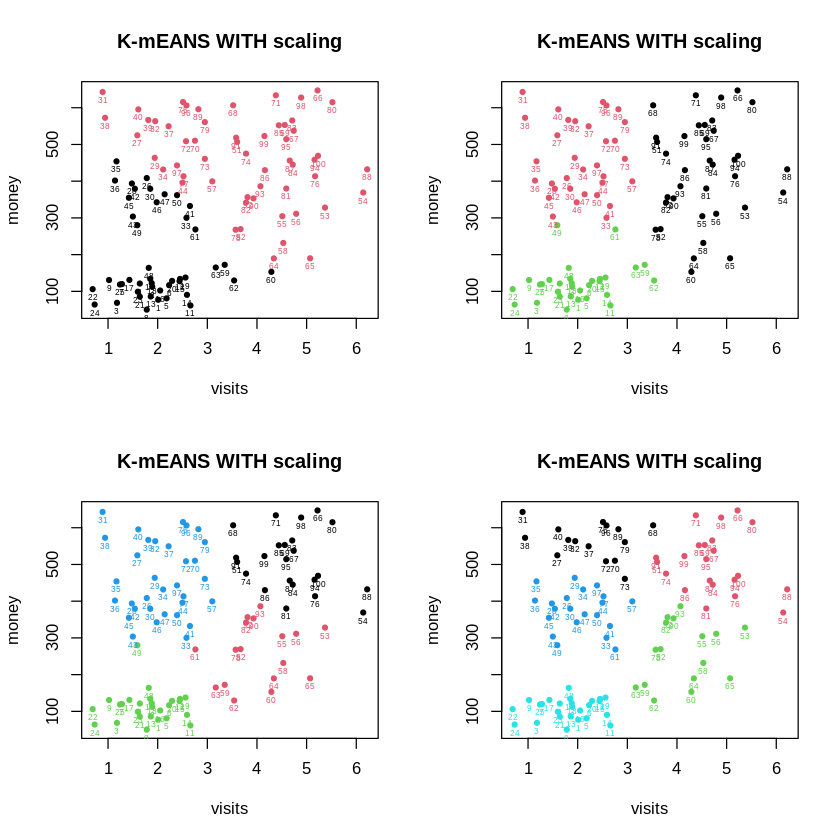

In [56]:
par(mfrow = c(2,2))
plot(shopping_data, col=kmeans_2$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_2$cluster, pos=1, offset=0.3, cex=0.5)
plot(shopping_data, col=kmeans_3$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_3$cluster, pos=1, offset=0.3, cex=0.5)
plot(shopping_data, col=kmeans_4$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_4$cluster, pos=1, offset=0.3, cex=0.5)
plot(shopping_data, col=kmeans_5$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_5$cluster, pos=1, offset=0.3, cex=0.5)

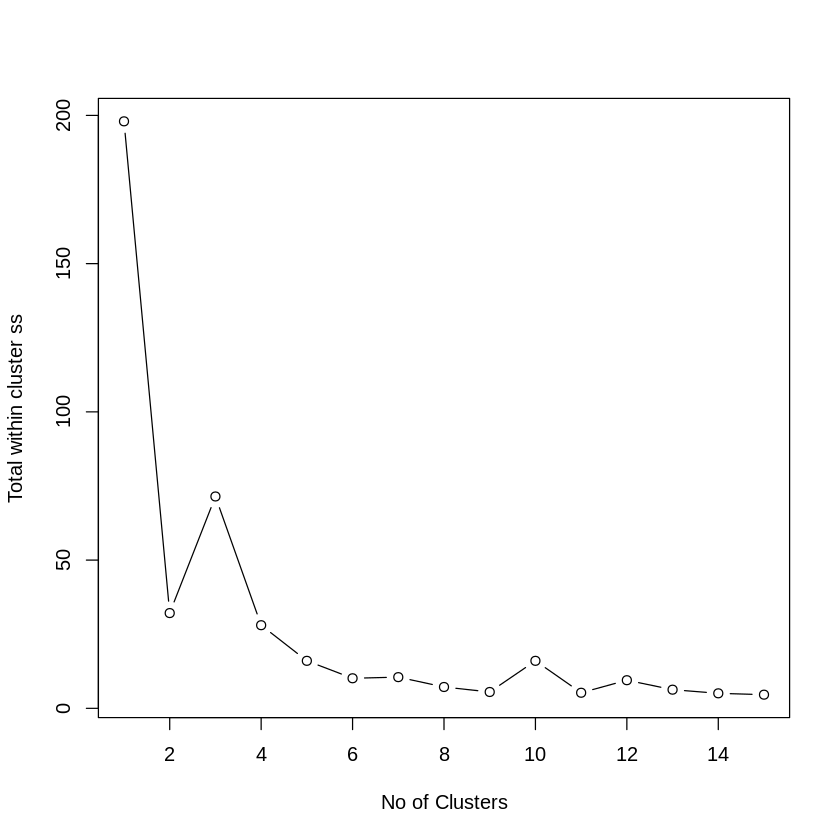

In [59]:
ss1 <- kmeans_2$totss
ss2 <- kmeans_2$withinss
ss3 <- kmeans_3$withinss
ss4 <- kmeans_4$withinss
ss5 <- kmeans_5$withinss

ss.vec <-c(ss1,ss2,ss3,ss4,ss5)
par(mfrow = c(1,1))
plot(ss.vec, type = "b", xlab="No of Clusters", ylab="Total within cluster ss")

In [60]:
#hierarchical Clustering
hc.res.average <-hclust(dist(shopping_data.sc),method="average")

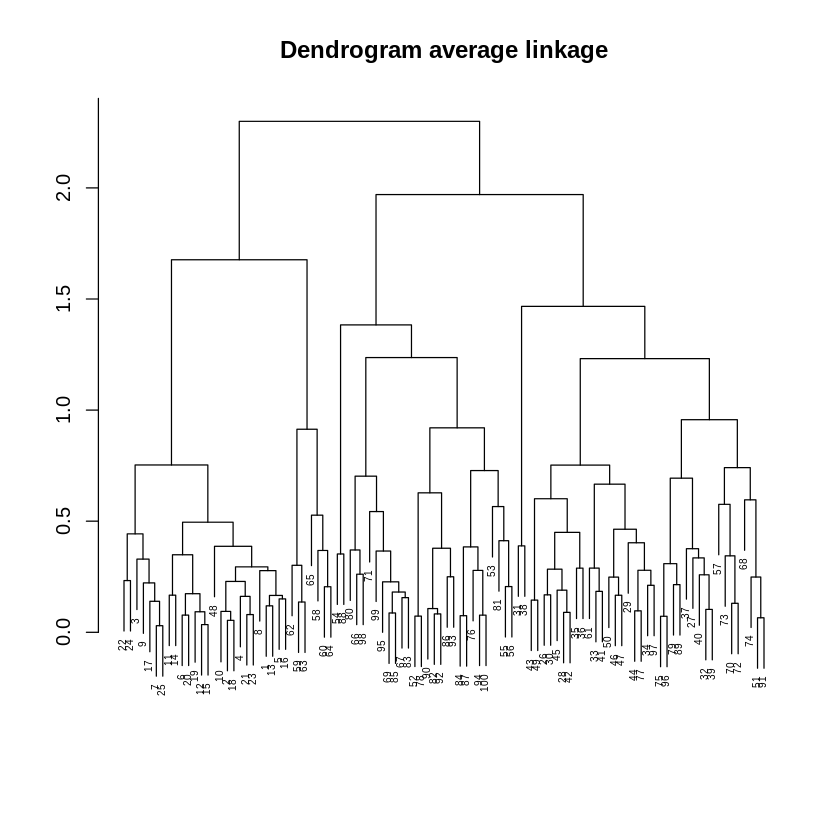

In [62]:
plot(hc.res.average, cex=0.5, main="Dendrogram average linkage",xlab="", ylab="", sub="")


In [67]:
cutree(hc.res.average, k=3)

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2
 [38] 2 2 2 2 2 2 2 2 2 2 1 2 2 2 3 3 3 3 3 2 1 1 1 2 1 1 1 1 3 3 2 3 2 3 2 2 2
 [75] 2 3 2 3 2 3 3 3 3 3 3 3 3 3 2 3 2 3 3 3 3 2 2 3 3 3

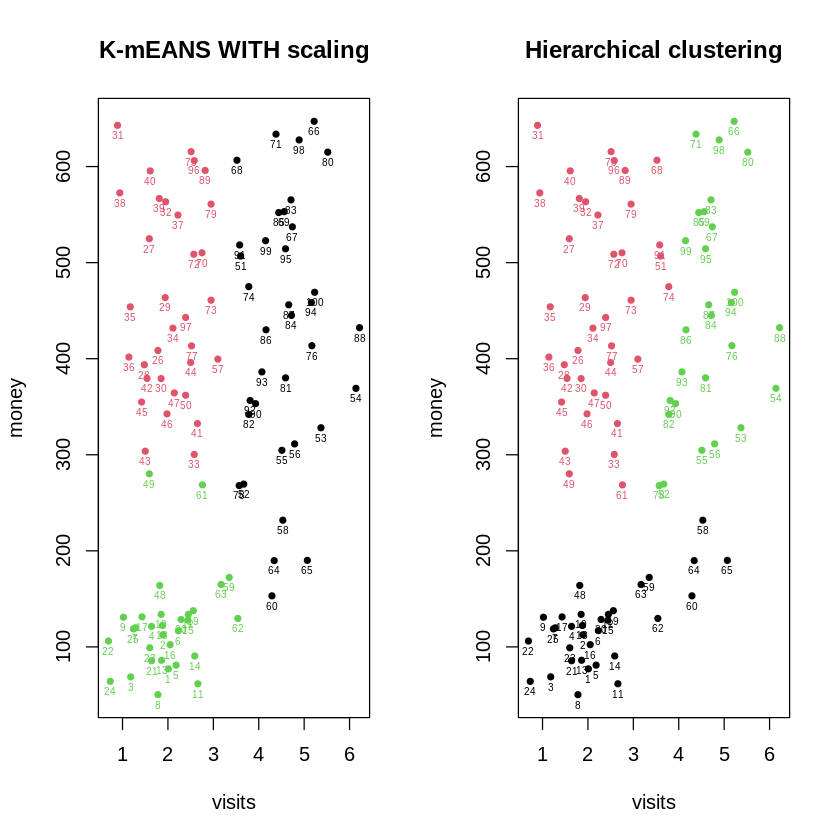

In [70]:
par(mfrow = c(1,2))
plot(shopping_data, col=kmeans_3$cluster,pch=20,main="K-mEANS WITH scaling")
text(shopping_data,labels=row.names(shopping_data),col=kmeans_3$cluster, pos=1, offset=0.3, cex=0.5)
plot(shopping_data,col=cutree(hc.res.average,k=3),pch=20, main="Hierarchical clustering")
text(shopping_data,labels=row.names(shopping_data),col=cutree(hc.res.average,k=3), pos=1, offset=0.3, cex=0.5)


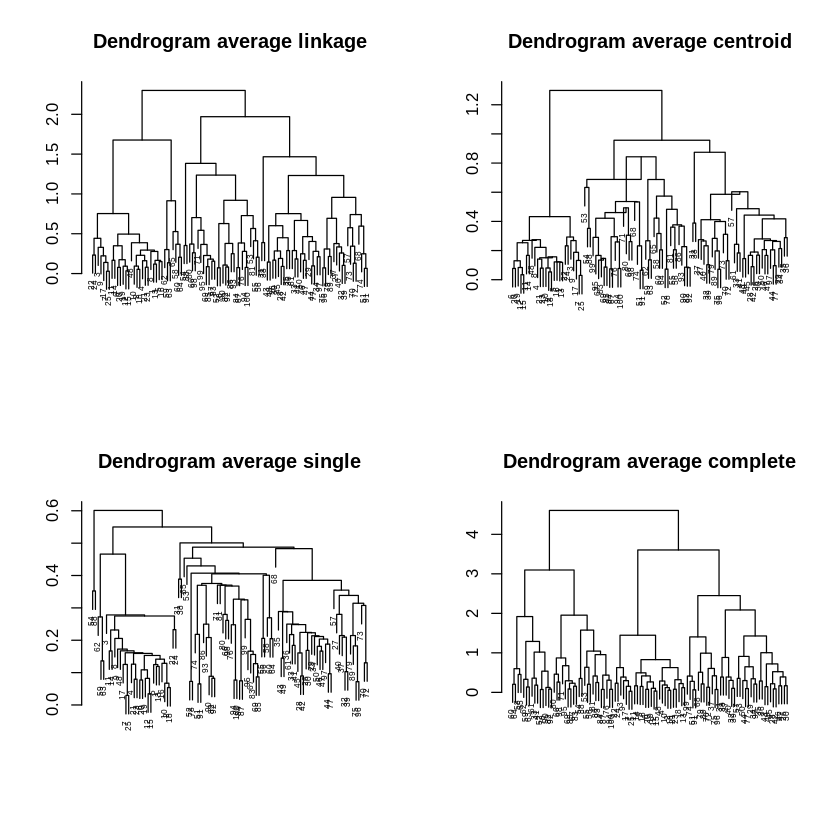

In [75]:
par(mfrow = c(2,2))
plot(hc.res.average, cex=0.5, main="Dendrogram average linkage",xlab="", ylab="", sub="")
hc.res.centroid <-hclust(dist(shopping_data.sc),method="centroid")
plot(hc.res.centroid, cex=0.5, main="Dendrogram average centroid",xlab="", ylab="", sub="")
hc.res.single <-hclust(dist(shopping_data.sc),method="single")
plot(hc.res.single, cex=0.5, main="Dendrogram average single",xlab="", ylab="", sub="")
hc.res.complete <-hclust(dist(shopping_data.sc),method="complete")
plot(hc.res.complete, cex=0.5, main="Dendrogram average complete",xlab="", ylab="", sub="")

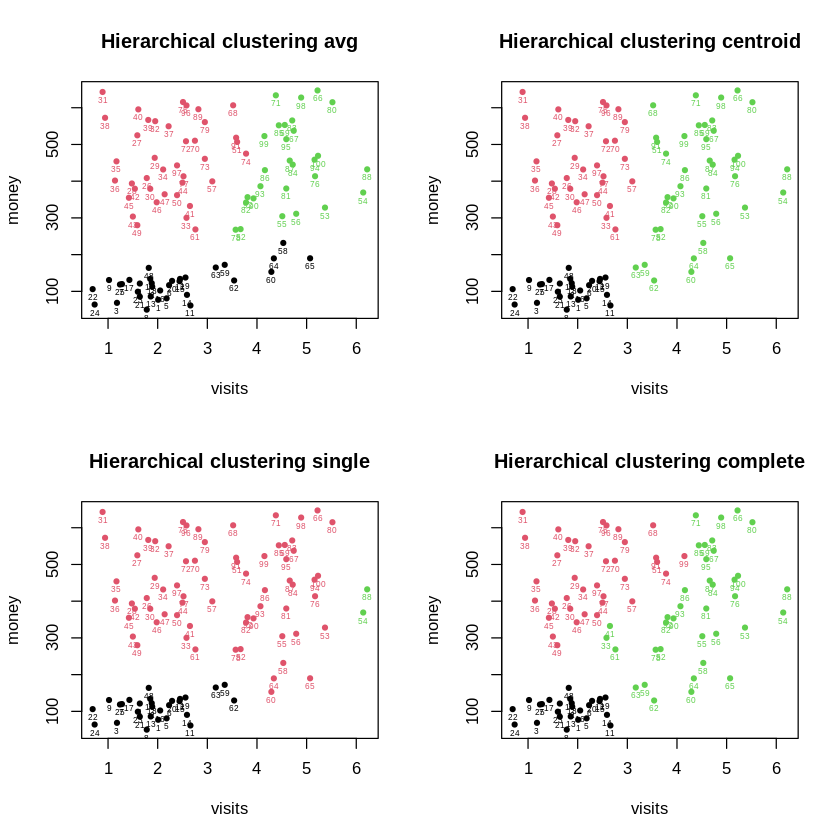

In [77]:
par(mfrow = c(2,2))
plot(shopping_data,col=cutree(hc.res.average,k=3),pch=20, main="Hierarchical clustering avg")
text(shopping_data,labels=row.names(shopping_data),col=cutree(hc.res.average,k=3), pos=1, offset=0.3, cex=0.5)
plot(shopping_data,col=cutree(hc.res.centroid,k=3),pch=20, main="Hierarchical clustering centroid")
text(shopping_data,labels=row.names(shopping_data),col=cutree(hc.res.centroid,k=3), pos=1, offset=0.3, cex=0.5)
plot(shopping_data,col=cutree(hc.res.single,k=3),pch=20, main="Hierarchical clustering single")
text(shopping_data,labels=row.names(shopping_data),col=cutree(hc.res.single,k=3), pos=1, offset=0.3, cex=0.5)
plot(shopping_data,col=cutree(hc.res.complete,k=3),pch=20, main="Hierarchical clustering complete")
text(shopping_data,labels=row.names(shopping_data),col=cutree(hc.res.complete,k=3), pos=1, offset=0.3, cex=0.5)